# Paper-exact reproduction: the addition circuit on Qwen3-4B

Reproduces **every** experiment of the biology paper's Addition dive
([biology.html §Addition](https://transformer-circuits.pub/2025/attribution-graphs/biology.html#dives-addition))
plus the methods-supplement interventions quoted there, on Qwen3-4B with
`mwhanna/qwen3-4b-transcoders` (per-layer). Paper reference values live in
`notes/biology_digest.md` (§A); the per-experiment verdict table is at the bottom and in
`DEVLOG.md`.

**Protocol notes**
- The paper's raw completion format `calc: a+b=` is used throughout (10,000-prompt operand
  grids, feature activity on the `=` token), with a chat fallback only if its accuracy
  collapses (it doesn't: ~78%).
- Qwen3 tokenizes numbers **digit-by-digit**, so the paper's single-token answer circuit
  splits into two per-digit circuits: the *first/magnitude* digit (plain prompt) and the
  *ones* digit (teacher-forced prefix). Position-sensitive experiments (operand grids,
  the Polymer reuse test) must be probed at the matching per-digit moment.
- The paper studies a prompt the model answers **correctly** (Haiku: 36+59). Qwen3-4B gets
  `calc: 36+59=` wrong, so the studied pair auto-switches to the nearest correct pair with
  the same digit classes (a%10, b%10, a+b preserved → the same `_6+_9 → sum=_95` structure).
- Steering conventions: the paper's multiple **M** is multiplicative (`a_new = M·a_clean`);
  our `m` is additive-delta (`m = M−1`): ablation M=0 ⇒ m=−1, sign-flip M=−1 ⇒ m=−2, paper
  "−2×" ⇒ m=−3.
- **v2 (this revision): constrained patching ONLY** — every intervention runs the paper's
  protocol (activations ≤ ℓ clamped at perturbed values, real model after ℓ; ℓ swept per
  experiment and stated per result). The v1 propagate-mode results live in git history and
  `DEVLOG.md`. **Supernodes are loaded from the reviewed artifact**
  `supernodes/addition_4b.json` (grid-evidenced scan by `build_supernodes.py`, membership
  by operand-grid receptive-field class — never influence); the notebook holds no
  selection logic. Graphs load from the `build_supernode_inputs.py` dumps when present.

All machinery lives in `addition_helper.py`; artifacts (explorer HTMLs, PNGs, JSONs) land
in `artifacts/paper_addition/<size>/`. Executed end-to-end on an A100-80GB (~15 min with the eager-decoder load and the graph dumps present; the 10,000-prompt grid probes dominate).

## What actually runs — exact model inputs, supernodes, artifacts

### Exact model inputs (all raw completions + one sink token, except introspection)

Every arithmetic prompt is the paper's raw `calc:` completion format — **no chat
template** — with one special token prepended as the attention sink (transcoders cannot
reconstruct position 0; `n_bos_tokens=1` everywhere):

| used by | exact model input | predicts |
|---|---|---|
| §0 accuracy grid | `<|endoftext|>calc: {a}+{b}=` for all a,b ∈ 0–99 (10,000 prompts) | leading digits of a+b |
| first-digit graph (§A) + its interventions | `<|endoftext|>calc: 46+49=` | `9` @ 0.5626 |
| ones graph (§A) + most interventions (§C/D/E-swap) | `<|endoftext|>calc: 46+49=9` — the first answer digit is **teacher-forced** | `5` @ 0.999 |
| §B operand grids | `calc: a+b=` probes over the full grid; input-token groups read at their **peak position**, answer/midlayer groups at the functional position | (feature activations) |
| §E polymer moments | `<|endoftext|>K. Whang, etc. Polymer, 36, 837, 1` (bare = magnitude moment) and `…, 1` + `99` (= `…199`, the **ones moment**, predicting the final `5`) | `995.` / `5` @ 0.982 |
| §E donor graph | `<|endoftext|>calc: 49+49=9` (teacher-forced ones graph of 9+9) | `8` |
| §F intermediate | `<|endoftext|>assert (4 + 5) * 3 ==` | ` 27` |
| §G introspection | **chat**, two turns: `Answer in one word. What is 46+49?` then `Briefly, how did you get that?` (+ 5 phrasing variants × 2 seeds at T=0.7; answer turn always greedy) | the explanation text |
| §H corpus | streamed C4 documents (no template) | (feature activations) |

### Supernode selection — the reviewed artifact (v2)

The paper groups features into supernodes **by hand** (human-curated concept groups).
v2 loads them from the **reviewed artifact** `supernodes/addition_4b.json`, emitted by
`build_supernodes.py`: every feature node of the pruned graphs is scanned and members
are selected by **operand-grid receptive-field class** (mod-10 residue lattices for
`input _6`/`_9`, the `band-a(~45)`/`band-b(~49)` pair for the magnitude supernodes,
lookup/sum geometry at the answer position, grid-verified `lookup(9,9)` donors on the
49+49 graph, and measured polymer-moment activity for the reuse set) — ranked by
activation, capped at 6 with runners-up in `overflow`, influence recorded as evidence
only, disjointness enforced. Each member carries its evidence (grid class, on-pair
fraction, label, example) inline; edit + re-approve the file to change any set.

### Artifact naming (`artifacts/paper_addition/<size>/`)

* `interventions_constrained.json` — the §C ladders (constrained patching, the only
  protocol in v2; chosen ℓ + full end-layer curves under `ell_choice`);
  `polymer_suppression_constrained.json` and `lookup_swap.json` likewise carry their ℓ
  and the swap's full p(`8`)-by-ℓ curve;
* `steer_compare.json` — §D smears with their ℓ;
* `grids_*.png` operand-grid panels, `taxonomy.json` their class labels,
  `graph_*.html` explorer pages, `accuracy_calc.npy` the §0 grid,
  `computed9_screen.json` / `introspection*.json` / `polymer_probe.json` /
  `corpus_examples.json` per-section records.

In [1]:
%matplotlib inline
import json

import addition_helper as A
import matplotlib.pyplot as plt
import numpy as np
import torch

from llm_circuits.models.qwen3 import load_qwen3
from llm_circuits.settings import artifacts_dir, default_device
from llm_circuits.transcoders.circuit_tracer_loader import load_transcoder

SIZE = "4b"
DEVICE = default_device()
OUT = artifacts_dir() / "paper_addition" / SIZE
OUT.mkdir(parents=True, exist_ok=True)

model, tokenizer = load_qwen3(SIZE, dtype_str="bf16", device_map=DEVICE)
model.eval()
# Eager decoders (lazy_decoder=False): graph builds and interventions decode every
# layer repeatedly, and lazy mode re-streams ~28 GB of W_dec per clean forward — the
# notebooks' dominant cost. Eager fits an A100-80GB for the 4b (CLAUDE.md perf notes).
# (The 8b encode-only case that must stay lazy lives in multilingual.ipynb section H.)
tc = load_transcoder(
    f"qwen3-{SIZE}", device=DEVICE, dtype=torch.bfloat16, lazy_decoder=False
).transcoder
N_LAYERS = len(tc)
A_VALS = list(range(100))
B_VALS = list(range(100))
print(f"Qwen3-{SIZE} on {DEVICE}; {N_LAYERS} transcoder layers; artifacts -> {OUT}")

[07/11/26 17:11:52] INFO     Loading model Qwen/Qwen3-4B (dtype=torch.bfloat16, device_map=cuda,                   
                             cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/models)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

[07/11/26 17:11:57] INFO     Loading transcoders from cache mwhanna/qwen3-4b-transcoders                           
                             (cache_dir=/teamspace/studios/this_studio/llm-circuits/.cache/transcoders)

Qwen3-4b on cuda; 36 transcoder layers; artifacts -> /teamspace/studios/this_studio/llm-circuits/artifacts/paper_addition/4b


## 0. Accuracy on the paper's 10,000-prompt grid + studied-pair selection

The paper computes operand plots over all `calc: a+b=` for a, b ∈ [0, 99]. We first check
the model can do the task in this format (gate: ≥50%, else fall back to the chat format and
report that), then pick the studied pair: the paper's 36+59 if correct, otherwise the
nearest correct same-digit-class pair.

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


accuracy[calc] = 77.7%
_6+_9 class accuracy: 46.0%; correct[36,59] = False
studied pair: 46+49=95 (SWITCHED from 36+59 — the model answers the paper's pair incorrectly)


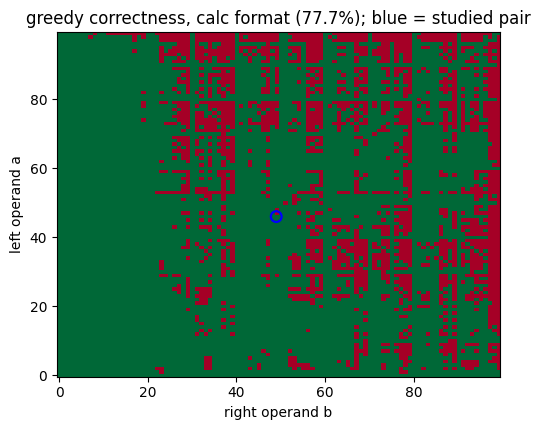

In [2]:
correct, _pred = A.accuracy_grid(model, tokenizer, A_VALS, B_VALS, style="calc")
acc_calc = float(correct.mean())
print(f"accuracy[calc] = {acc_calc:.1%}")
STYLE = "calc"
if acc_calc < 0.5:  # paper-format fallback (not needed for 4b)
    correct, _pred = A.accuracy_grid(model, tokenizer, A_VALS, B_VALS, style="chat")
    STYLE = "chat"
    print(f"accuracy[chat] = {float(correct.mean()):.1%} -> falling back to chat format")
np.save(OUT / f"accuracy_{STYLE}.npy", correct)

class69 = np.mean(
    [correct[a, b] for a in range(100) for b in range(100) if a % 10 == 6 and b % 10 == 9]
)
print(f"_6+_9 class accuracy: {class69:.1%}; correct[36,59] = {bool(correct[36, 59])}")
A0, B0, switched = A.pick_studied_pair(36, 59, correct)
print(
    f"studied pair: {A0}+{B0}={A0 + B0}"
    + (
        " (SWITCHED from 36+59 — the model answers the paper's pair incorrectly)"
        if switched
        else ""
    )
)

fig, ax = plt.subplots(figsize=(5.2, 4.4))
ax.imshow(correct, origin="lower", cmap="RdYlGn", aspect="auto", interpolation="nearest")
ax.scatter([B0], [A0], s=60, facecolors="none", edgecolors="blue", linewidths=1.6)
ax.set_xlabel("right operand b")
ax.set_ylabel("left operand a")
ax.set_title(
    f"greedy correctness, {STYLE} format ({float(correct.mean()):.1%}); blue = studied pair"
)
plt.tight_layout()
plt.show()

## A. Attribution graphs — the two per-digit circuits (Fig A2)

The paper's graph runs from the prompt to the single answer token "95". With digit-split
tokenization we build two graphs: `target="first"` attributes the argmax next token after
`=` (the magnitude digit, expect `9`), and `target="ones"` teacher-forces the leading
digit(s) and attributes the ground-truth ones digit (expect `5`). Interactive explorer
HTMLs are written next to this notebook's other artifacts.

In [3]:
# Attribution graphs for the studied pair (Fig A2's two per-digit circuits). v2
# pipeline: build_supernode_inputs.py persists the pruned graphs once; the notebook
# LOADS those dumps when present, so interventions run against literally the graphs
# the supernode selection/review saw (a fresh node rebuilds identically — bf16
# determinism has held across five A100s). Explorer HTMLs are written by the
# annotate cell at the end of section E, with the supernodes pre-loaded as groups.
SN_INPUTS = artifacts_dir() / "supernode_inputs" / SIZE
_mpath = SN_INPUTS / "manifest.json"
manifest = json.loads(_mpath.read_text()) if _mpath.exists() else None

graphs, answers, ids = {}, {}, {}
for key, target in (("ones", "ones"), ("first", "first")):
    dump = SN_INPUTS / f"graph_{key}.json"
    if manifest is not None and dump.exists():
        graphs[key] = json.loads(dump.read_text())
        answers[key] = manifest["graphs"][key]["answer_token_id"]
        ids[key] = A.addition_input_ids(tokenizer, A0, B0, DEVICE, target=target, style=STYLE)
        assert ids[key].shape[1] == manifest["graphs"][key]["n_tokens"]
        n_feat = sum(1 for n in graphs[key]["nodes"] if n["node_type"] == "feature")
        print(
            f"{key}: loaded dump ({n_feat} feature nodes; built at "
            f"{manifest['graphs'][key].get('node_threshold', 0.8)} prune, git "
            f"{manifest['git']}), answer {tokenizer.decode([answers[key]])!r}"
        )
    else:
        graphs[key], answers[key], ids[key] = A.build_addition_graph(
            model,
            tc,
            tokenizer,
            A0,
            B0,
            target=target,
            style=STYLE,
            size_key=SIZE,
        )
        n_feat = sum(1 for n in graphs[key]["nodes"] if n["node_type"] == "feature")
        print(f"{key}: built ({n_feat} feature nodes), answer {tokenizer.decode([answers[key]])!r}")

ones: loaded dump (1347 feature nodes; built at 0.8 prune, git 9151262), answer '5'


first: loaded dump (1490 feature nodes; built at 0.8 prune, git 9151262), answer '9'


## B. Operand grids + taxonomy (Fig A1)

Feature activity over all 10,000 prompts, probed at each feature's **functional position**:
answer features of the first-digit circuit at the `=` token (plain prompt), answer/mid-layer
features of the ones circuit at the teacher-forced predict-ones position, and **input-token
features at their peak over prompt positions** (they are silent at the final position).
Input supernodes are selected from **early layers** (< n_layers/4) of the ones graph at the
operand digit positions — the paper's `_6`/`_9`/`~magnitude` input features are
detokenization-level, and without the layer cap late-layer aggregation features crowd them
out of the influence ranking.

Paper taxonomy to look for: **diagonals** = sum features, **isolated/repeating points** =
lookup-table features, **repeating stripes** = mod-10, **smears** = low-precision,
**horizontal/vertical stripes** = single-operand sensitivity (the classifier labels clean
one-operand bands `band-a(~M)`/`band-b(~M)` — the paper's `~30`/`~59` magnitude-input
signature).

The `add_function` group probes features living on the `+`/`=` operator tokens.
**Taxonomy note (recheck 2026-07-10):** the paper's *Add Function* class is
operand-conditioned — "horizontal or vertical bars; one addend satisfies some condition"
(`add _9`, `add ~57`) — whereas an operand-**uniform** plot is the signature of its
separate *Mostly Active* class ("active on the = token of most of the 10,000 prompts").
The operator-token features found here grid as operand-uniform, i.e. they evidence the
mostly-active / "this is addition" context class. The paper's stripe-like add-function
analogue (one-operand conditions read where the computation happens) is hunted by the
**`answer_pos_pool`** panel: influence-top features of the ones graph **at the
predict-ones position** (layers < 3·N/4), probed on the ones-moment grids — genuine
one-operand stripes/bands there are the `add _9`/`add ~57` analogues (selected as
`add_func_candidates` in the next cell).

**The descriptive panels below vs the reviewed supernodes.** The seven
`grids_*.png` panels are influence-top **candidate pools**, kept as the Fig A1
*figure* deliverable and for hunting (they are NOT the selection source in v2 — the
reviewed supernode file is):

* `input_a` / `input_b` — top features at the a-/b-operand digit tokens (early
  layers): where exact-value, mod-10 and magnitude-band input features live.
* `add_function` — top features at the operator tokens (`+`, `=`): the v1 hunt for
  the paper's add-function class (found the "mostly-active" operator signature
  instead).
* `midlayer` — mid-layer (N/4–3N/4) features at the predict-ones position: the
  lookup-table workhorse pool.
* `answer_ones` / `answer_first` — late-layer features at each circuit's answer
  position: sum/say candidates (ones) and low-precision sum candidates (first digit).
* `answer_pos_pool` — the third-session add-function hunt at the predict-ones
  position (the measured negative).

The **supernode member figure** (`grids_supernodes.png`, cell below) shows the
operand grid of every reviewed member, one supernode per row — the membership
evidence in a single view.

In [4]:
groups = {}
groups["answer_first"] = [
    (f["layer"], f["feature_idx"])
    for f in A.answer_features(graphs["first"], top_k=8, numeric_only=True)
]
groups["answer_ones"] = [
    (f["layer"], f["feature_idx"])
    for f in A.answer_features(graphs["ones"], top_k=8, numeric_only=True)
]

mid = [
    n
    for n in graphs["ones"]["nodes"]
    if n["node_type"] == "feature" and N_LAYERS // 4 <= n["layer"] < 3 * N_LAYERS // 4
]
mid.sort(key=lambda n: n.get("influence", 0.0), reverse=True)
groups["midlayer"] = [(n["layer"], n["feature_idx"]) for n in mid[:16]]

pos = A.digit_token_positions(tokenizer, ids["ones"], A0, B0)
lmax_input = max(1, N_LAYERS // 4)
groups["input_a"] = [
    (L, i)
    for (L, i, _) in A.position_features(graphs["ones"], pos["a_digits"], 16, max_layer=lmax_input)
]
groups["input_b"] = [
    (L, i)
    for (L, i, _) in A.position_features(graphs["ones"], pos["b_digits"], 16, max_layer=lmax_input)
]
# the paper's ADD-FUNCTION class: features living on the +/= operator tokens (no layer
# cap — they sit mid-level, between the detokenized operands and the lookups they feed)
groups["add_function"] = [
    (L, i) for (L, i, _) in A.position_features(graphs["ones"], pos["plus"] + pos["eq"], 16)
]
# ... and where the paper ACTUALLY reads that class (recheck F3): one-operand stripe/band
# conditions at the ANSWER position ("add _9", "add ~57"). Pool = influence-top features
# of the ones graph at the predict-ones position, below the late aggregation layers
# (< 3N/4), probed on the ones-moment grids (routed in grids_for).
last_ones = ids["ones"].shape[1] - 1
groups["answer_pos_pool"] = [
    (L, i)
    for (L, i, _) in A.position_features(
        graphs["ones"], [last_ones], 24, max_layer=3 * N_LAYERS // 4
    )
]

all_feats = sorted({f for g in groups.values() for f in g})
print(
    f"probing {len(all_feats)} features x 3 probe modes over {len(A_VALS) * len(B_VALS)} prompts ..."
)
probe_first = "last" if STYLE == "calc" else "first"
grids_first = A.feature_grids(
    model, tc, all_feats, A_VALS, B_VALS, tokenizer, probe=probe_first, style=STYLE
)
grids_ones = A.feature_grids(
    model, tc, all_feats, A_VALS, B_VALS, tokenizer, probe="ones", style=STYLE
)
grids_peak = (
    grids_first
    if probe_first == "first"
    else A.feature_grids(
        model, tc, all_feats, A_VALS, B_VALS, tokenizer, probe="first", style=STYLE
    )
)


def grids_for(gname):
    if gname in ("answer_ones", "midlayer", "answer_pos_pool"):
        return grids_ones
    if gname in ("input_a", "input_b", "add_function"):
        return grids_peak  # operand/operator-token features are silent at the final position
    return grids_first


taxonomy = {}
for gname, feats in groups.items():
    taxonomy[gname] = {
        f"L{L}f{i}": A.periodicity_report(grids_for(gname)[(L, i)], A_VALS, B_VALS)
        for (L, i) in feats
    }
    counts = {}
    for rep in taxonomy[gname].values():
        key = str(rep["label"]).split("(")[0]
        counts[key] = counts.get(key, 0) + 1
    print(f"taxonomy[{gname}]: {counts}")

probing 77 features x 3 probe modes over 10000 prompts ...


taxonomy[answer_first]: {'mixed': 7, 'magnitude-diag': 1}
taxonomy[answer_ones]: {'mixed': 3, 'mod10-sum': 4, 'lookup': 1}


taxonomy[midlayer]: {'lookup': 5, 'mixed': 7, 'sparse': 2, 'mod10-sum': 1, 'inactive': 1}


taxonomy[input_a]: {'mixed': 4, 'lookup': 10, 'band-a': 1}


taxonomy[input_b]: {'lookup': 11, 'mixed': 4, 'band-b': 1}


taxonomy[add_function]: {'mixed': 15, 'lookup': 1}


taxonomy[answer_pos_pool]: {'lookup': 7, 'mixed': 14, 'mod10-sum': 1, 'band-b': 1, 'magnitude-diag': 1}


In [5]:
# v2: supernodes are LOADED from the reviewed artifact — grid-evidenced, scan-based
# selection (build_supernodes.py; membership by operand-grid receptive-field class,
# ranked by activation, influence recorded as evidence only). The notebook contains
# no selection logic; edit + re-approve notebooks/supernodes/addition_4b.json to
# change any set.
SN = A.load_supernodes(f"supernodes/addition_{SIZE}.json")
with open(f"supernodes/addition_{SIZE}.json") as _f:
    print(json.load(_f).get("review_log", ""))

sel = {
    "input_6": A.supernode_members(SN["input _6"], with_acts=False),
    "input_9": A.supernode_members(SN["input _9"], with_acts=False),
    "input_mag": A.supernode_members(SN["magnitude ~46"], with_acts=False)
    + A.supernode_members(SN["magnitude ~49"], with_acts=False),
    "lookup": A.supernode_members(SN["lookup (6,9-class)"], with_acts=False),
    "sum": A.supernode_members(SN["sum = _5"], with_acts=False),
}
lowprec = A.supernode_members(SN["sum ~95 (low precision)"], with_acts=False)
donors = A.supernode_members(SN["lookup (9,9) donors"])  # acts = donor-graph values
polymer_lookups = A.supernode_members(SN["polymer-active lookups"])  # acts = ones-moment
for name, sn in SN.items():
    classes = sorted({str(m["evidence"].get("grid_class")) for m in sn["members"]})
    print(f"{name:28s} n={len(sn['members'])} pos={sn['position']!s:6s} classes={classes}")

2026-07-11: grid-principled selection reviewed by delegation (user waived manual gate for addition). One action: lookup (6,9-class) L33f109892 rejected (20% on-pair) -> L24f99664 promoted. All other members approved as proposed.
input _6                     n=6 pos=5      classes=['lookup(a%10=6,b%10=6)']
input _9                     n=6 pos=8      classes=['lookup(a%10=4,b%10=9)', 'lookup(a%10=9,b%10=9)']
magnitude ~46                n=2 pos=None   classes=['band-a(~40)', 'band-a(~45)']
magnitude ~49                n=1 pos=None   classes=['band-b(~49)']
lookup (6,9-class)           n=6 pos=final  classes=['lookup(a%10=3,b%10=3)', 'lookup(a%10=3,b%10=9)', 'lookup(a%10=4,b%10=4)', 'lookup(a%10=5,b%10=9)', 'lookup(a%10=6,b%10=6)', 'lookup(a%10=9,b%10=9)']
sum = _5                     n=6 pos=final  classes=['mod10-sum(r5)']
sum ~95 (low precision)      n=4 pos=final  classes=['magnitude-diag']
lookup (9,9) donors          n=6 pos=final  classes=['lookup(a%10=9,b%10=9)']
polymer-active lo

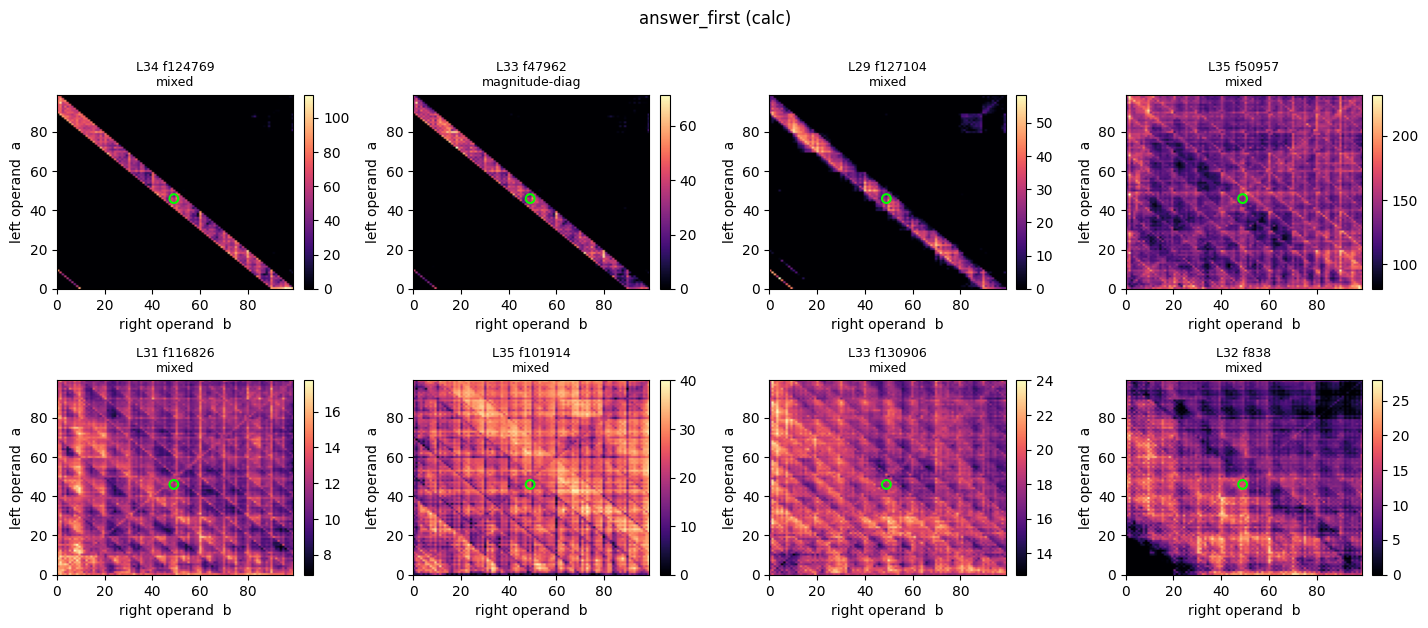

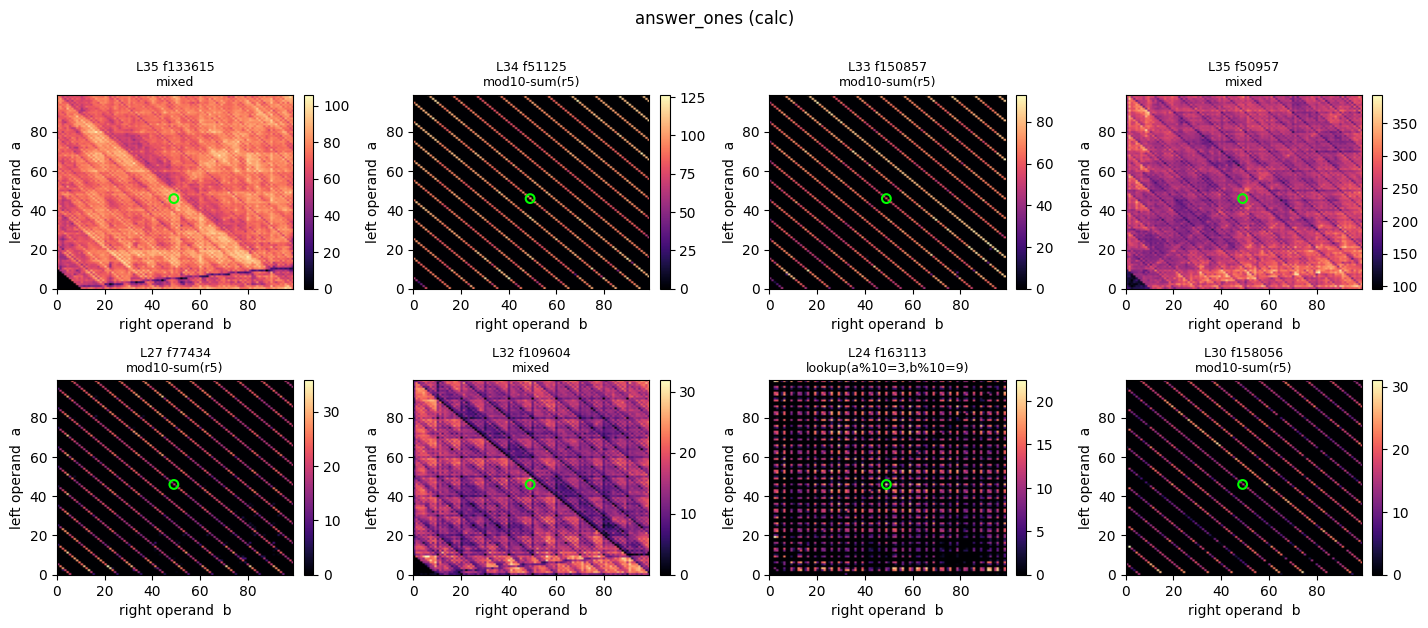

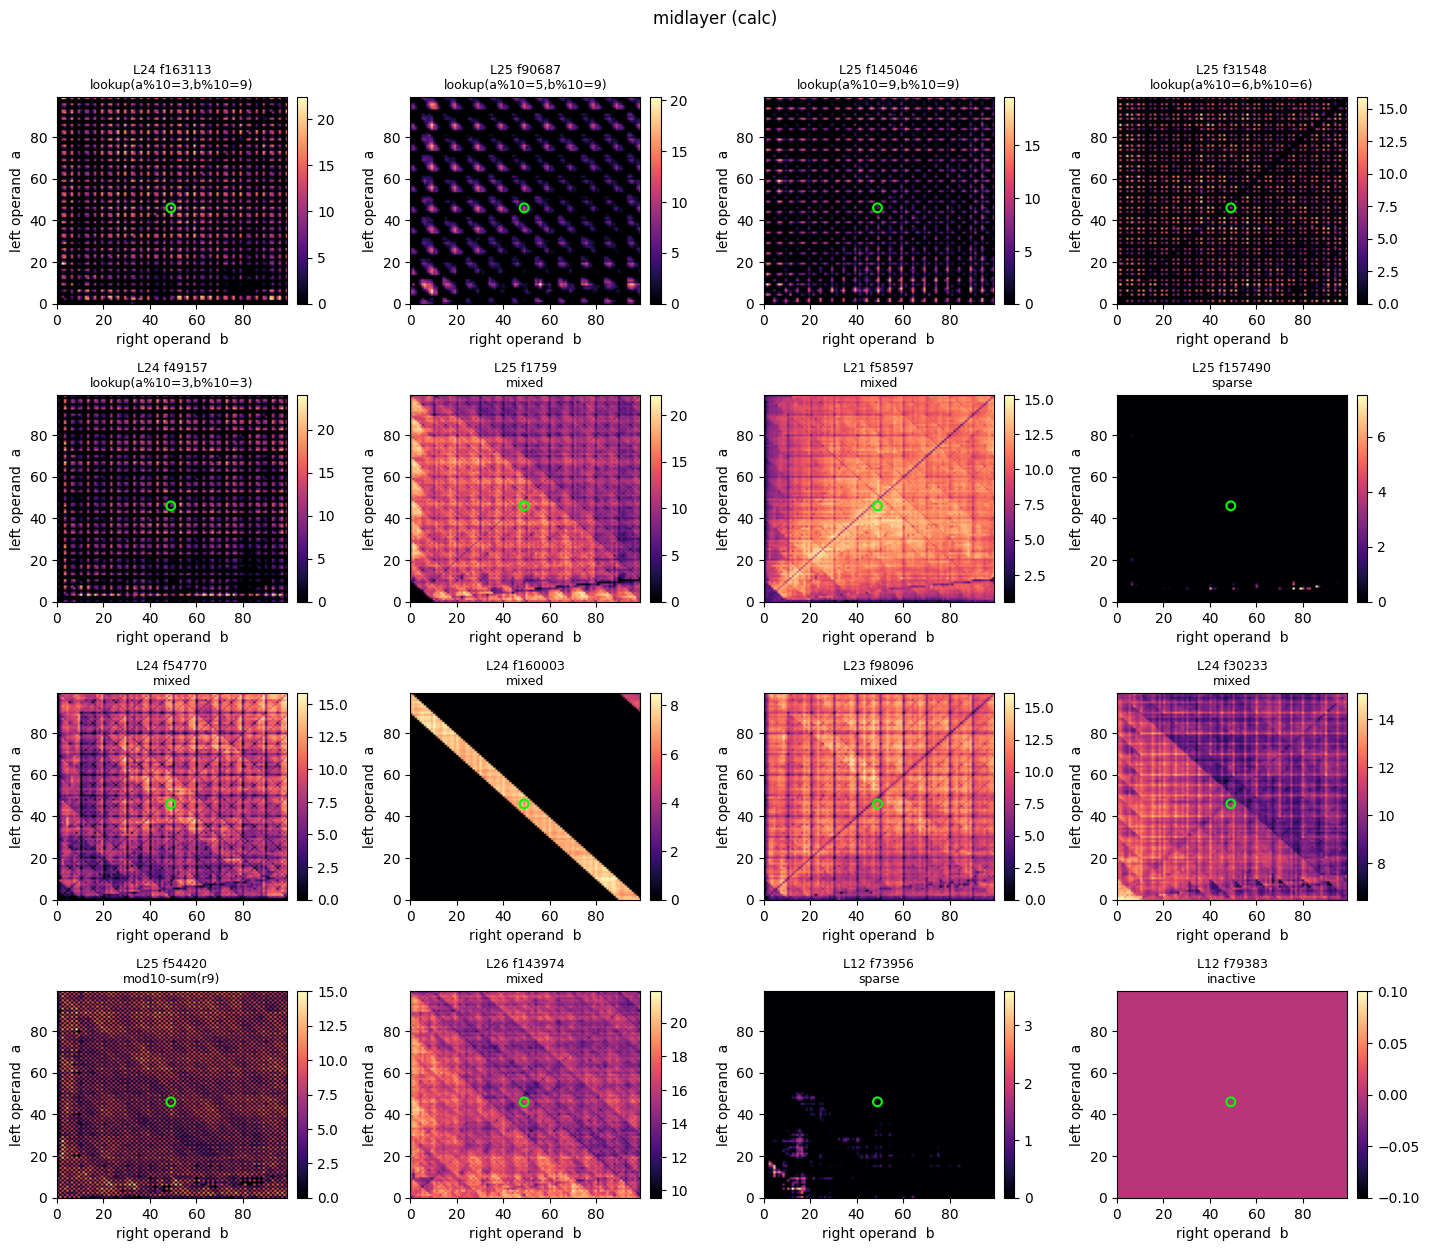

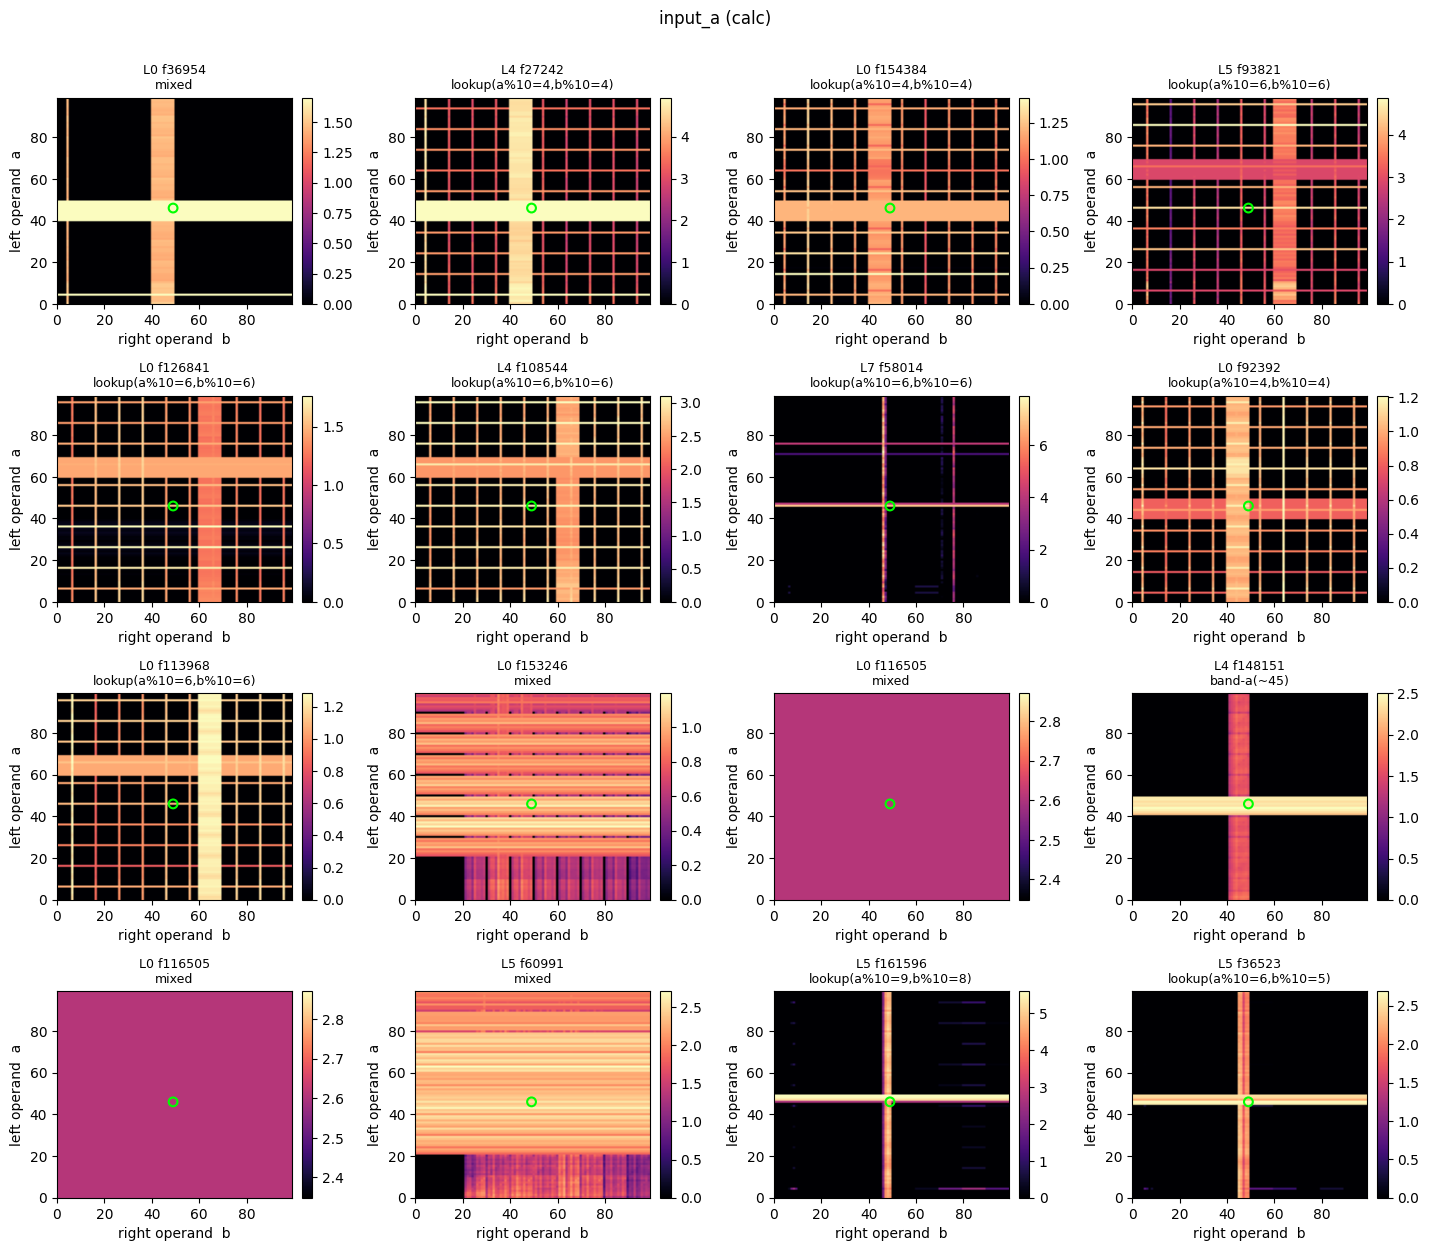

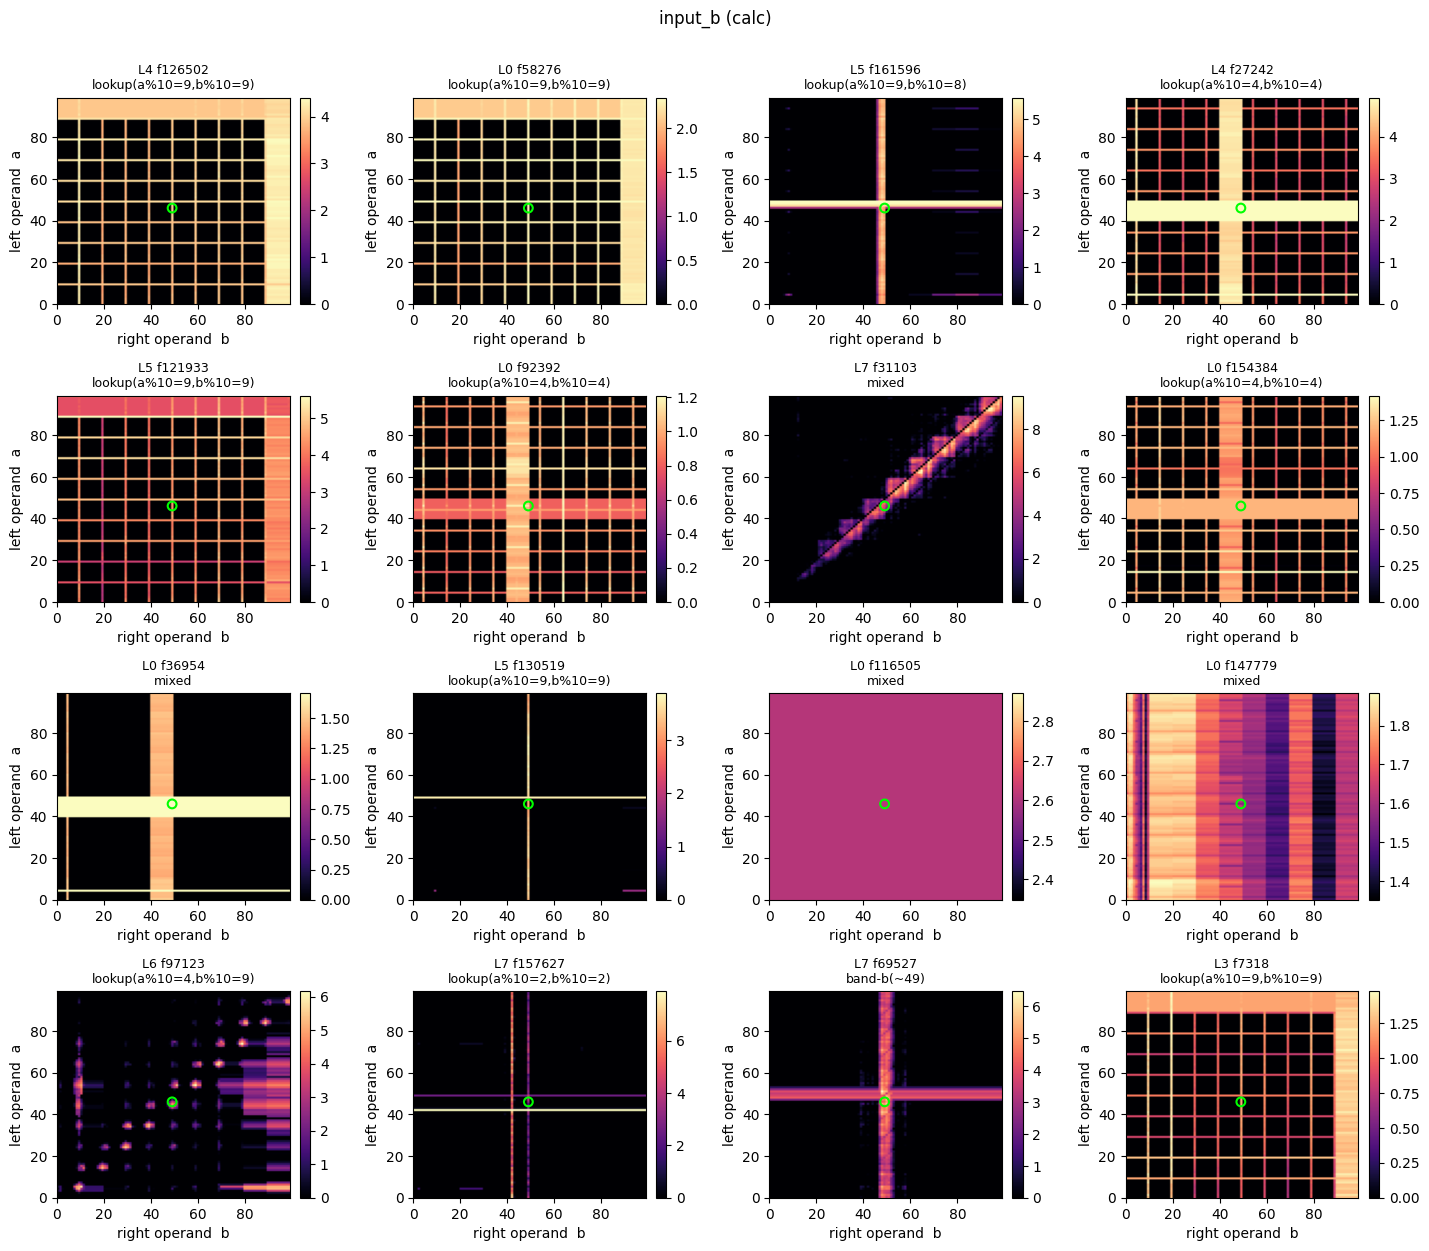

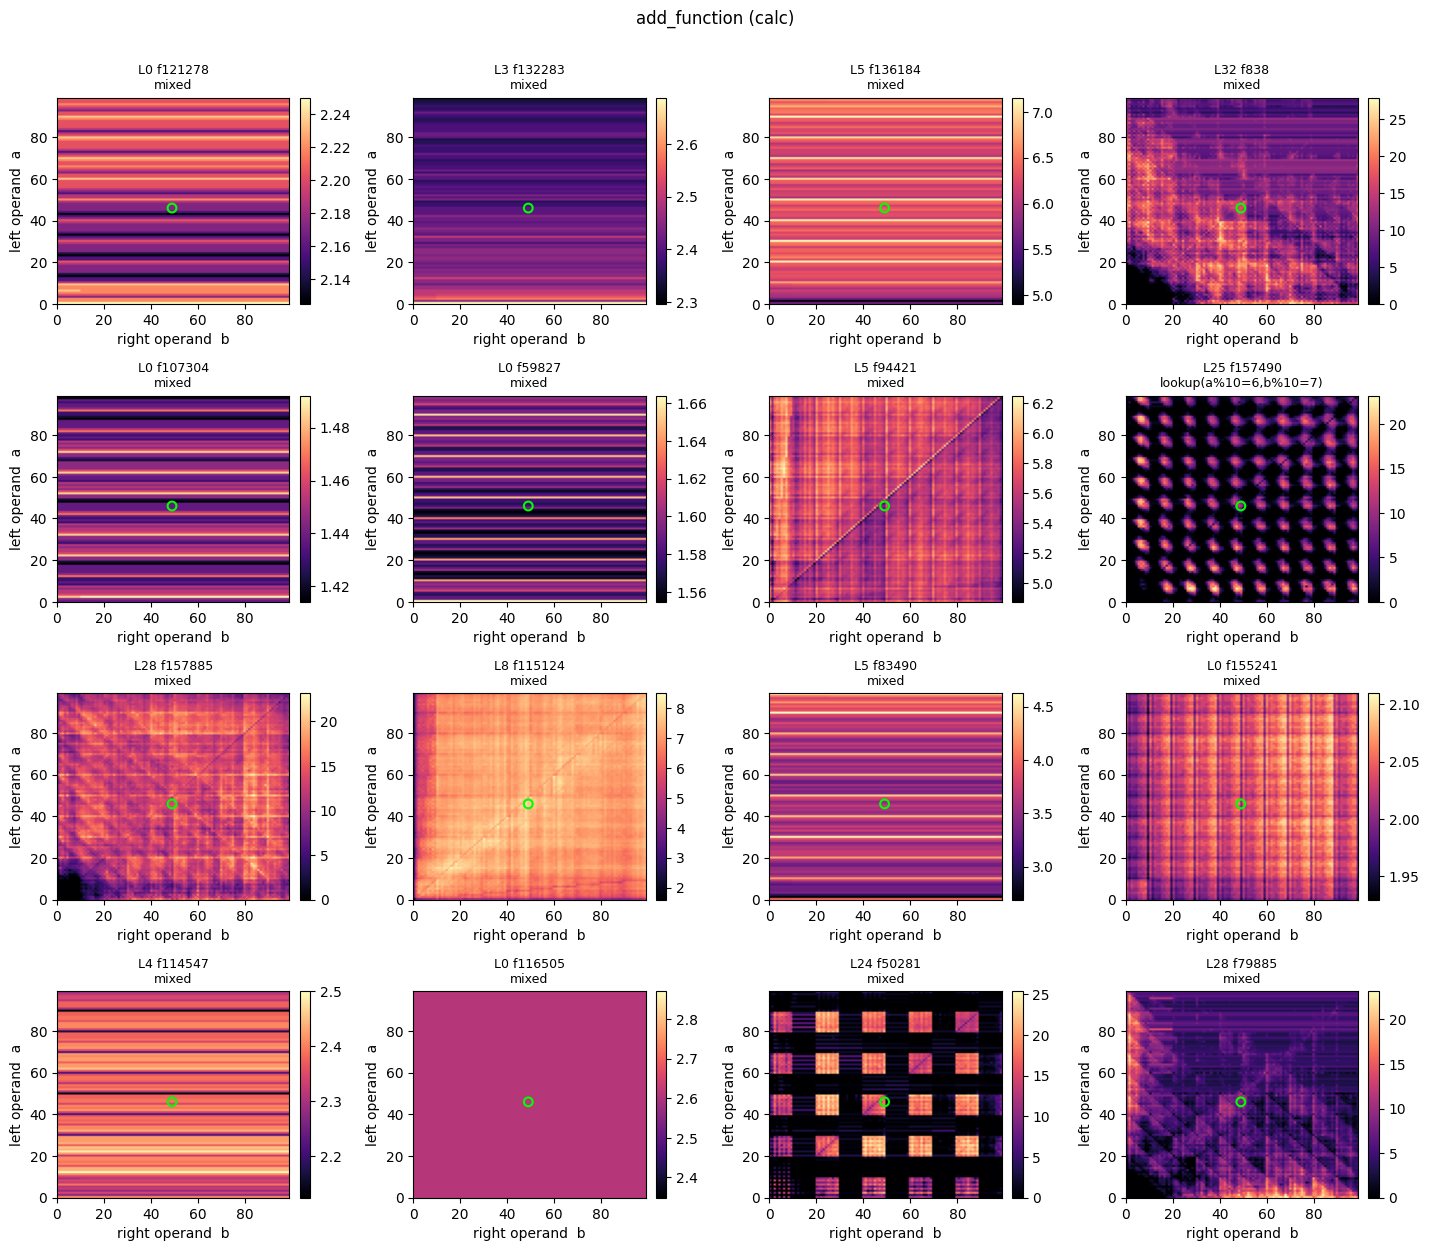

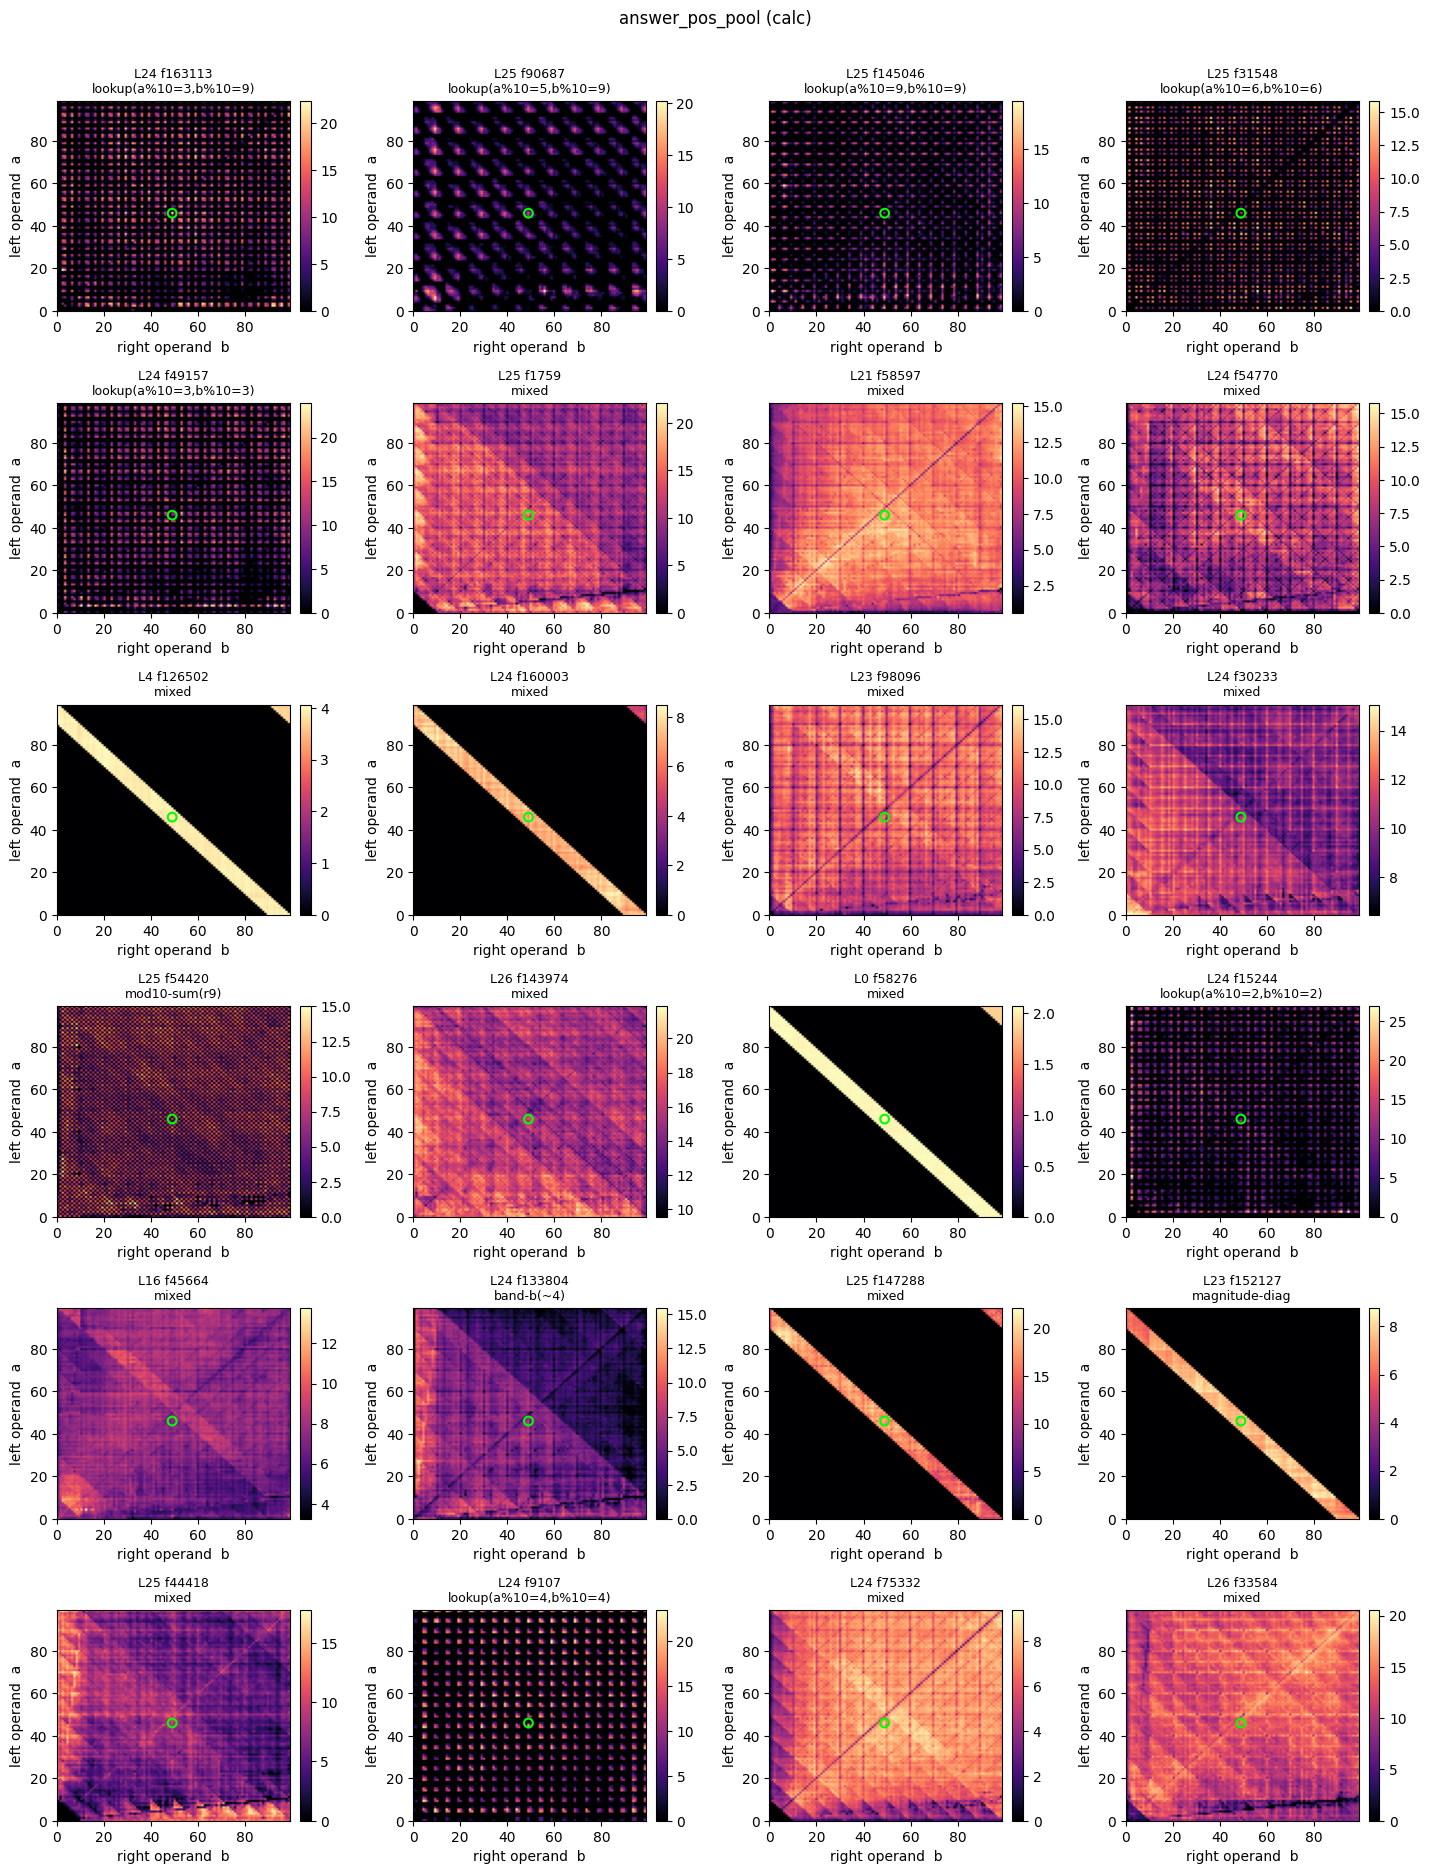

In [6]:
for gname, feats in groups.items():
    if not feats:
        continue
    fig = A.plot_grid_panels(
        feats,
        grids_for(gname),
        A_VALS,
        B_VALS,
        mark=(A0, B0),
        title=f"{gname} ({STYLE})",
        path=OUT / f"grids_{gname}.png",
    )
    plt.show()

In [ ]:
# Operand grids of every REVIEWED supernode member (one supernode per row) — the
# membership evidence in one figure, straight from the persisted evidence pass.
znpz = np.load(SN_INPUTS / "grids.npz")
probe_for = {
    "input _6": "first",
    "input _9": "first",
    "input 46 (exact)": "first",
    "input 49 (exact)": "first",
    "magnitude ~46": "first",
    "magnitude ~49": "first",
    "lookup (6,9-class)": "ones",
    "sum = _5": "ones",
    "lookup (9,9) donors": "ones",
    "polymer-active lookups": "ones",
    "sum ~95 (low precision)": "last",
    "magnitude lookup (~46+~49)": "last",
}
rows = [n for n in probe_for if n in SN and SN[n]["members"]]
ncols = max(len(SN[n]["members"]) for n in rows)
fig, axes = plt.subplots(len(rows), ncols, figsize=(1.9 * ncols, 2.1 * len(rows)), squeeze=False)
for ri, name in enumerate(rows):
    probe = probe_for[name]
    feats = [tuple(int(v) for v in x) for x in znpz[f"{probe}_features"]]
    fidx = {f: i for i, f in enumerate(feats)}
    arr = znpz[f"{probe}_grids"]
    for ci in range(ncols):
        ax = axes[ri][ci]
        if ci >= len(SN[name]["members"]):
            ax.axis("off")
            continue
        m = SN[name]["members"][ci]
        k = (m["layer"], m["feature"])
        if k in fidx:
            ax.imshow(arr[fidx[k]], origin="lower", cmap="viridis", aspect="auto")
        ax.set_title(
            f"L{m['layer']}f{m['feature']}\n{m['evidence'].get('grid_class')}", fontsize=6.5
        )
        ax.set_xticks([])
        ax.set_yticks([])
        if ci == 0:
            ax.set_ylabel(name, fontsize=8, rotation=0, ha="right", va="center")
fig.suptitle(
    "Reviewed supernode members — operand grids (x = b, y = a; probe per row's circuit)",
    fontsize=11,
    y=1.002,
)
plt.tight_layout()
plt.savefig(OUT / "grids_supernodes.png", dpi=130, bbox_inches="tight")
plt.show()

## C. Input-supernode suppressions (methods supplement)

Paper outcomes on 36+59: suppress `_6` → output **98** (the ones circuit computes 9+9);
suppress `_9` → **91** ("not 92, so such numerology must be taken with a grain of salt");
inhibit the `~30`/`~59` magnitude inputs → low-precision features suppressed **"while
leaving the ones-digit pathway alone"**.

**Protocol (v2, constrained-only):** every intervention runs under the paper's
**constrained patching** — activations up to a chosen intervention layer ℓ clamped at
their perturbed values, the real model after ℓ — with ℓ chosen the paper's way per
suppression: sweep the patch end layer over [l_max, n_layers−1] at the paper's prose
strength (−1× ⇒ m=−2), take the most suppressive on the clean answer's logit
(suppress-`_6`/`_9`: the ones graph; the magnitude supernode: the first-digit graph,
where the paper's effect lives), then run the full **m=−1/−2/−3 ladder** (ablation /
prose −1× / figure −2×) at that fixed ℓ. Readout rows at layers ≤ ℓ are pinned by the
protocol and dropped from the prints. Supernodes and steering positions come from the
reviewed file (section B): `input _6` at the a-ones-digit token, `input _9` at the
b-ones-digit token, the `~46`/`~49` band pair at every position. The paper's other
readout half — the low-precision features on the first-digit graph — uses the
`sum ~95 (low precision)` supernode. (The v1 propagate-mode ladders and the loose
catch-all supernode live in git history / DEVLOG, not in this notebook.)

In [7]:
def feats_with_acts(keys, graph_key="ones"):
    by_key = {
        (n["layer"], n["feature_idx"]): float(n.get("activation", 0.0))
        for n in graphs[graph_key]["nodes"]
        if n["node_type"] == "feature"
    }
    return [(L, i, by_key.get((L, i), 0.0)) for L, i in keys]


last = ids["ones"].shape[1] - 1
first_last = ids["first"].shape[1] - 1
readout = [(L, i, last) for L, i in sel["lookup"] + sel["sum"]]
readout_first = [(L, i, first_last) for L, i in lowprec]

interventions_c, ell_choice = {}, {}
for name, keys, p0, metric_graph in [
    ("suppress_6", sel["input_6"], SN["input _6"]["position"], "ones"),
    ("suppress_9", sel["input_9"], SN["input _9"]["position"], "ones"),
    ("inhibit_magnitude", sel["input_mag"], None, "first"),
]:
    ivs = A.steer_interventions(feats_with_acts(keys), m=-2.0, position=p0)
    ell, sweep = A.choose_patch_end_layer(
        model, tc, ids[metric_graph], ivs, answers[metric_graph], mode="suppress"
    )
    ell_choice[name] = {
        "l_max": sweep.end_layers[0],
        "ell": ell,
        "end_layers": sweep.end_layers,
        "probs": [round(p, 4) for p in sweep.probs],
        "baseline_prob": round(sweep.baseline_prob, 4),
    }
    tname = tokenizer.decode([answers[metric_graph]])
    print(
        f"{name}: l_max={sweep.end_layers[0]}, chosen ell={ell} — p({tname!r}) "
        f"{sweep.baseline_prob:.3f} -> {sweep.probs[sweep.end_layers.index(ell)]:.3f} "
        f"at m=-2 on the {metric_graph} graph"
    )
    for m in (-1.0, -2.0, -3.0):
        rep = A.steer_and_report(
            model,
            tc,
            ids["ones"],
            feats_with_acts(keys),
            tokenizer,
            m=m,
            patch_end_layer=ell,
            position=p0,
            readout=readout,
        )
        interventions_c[f"{name}_m{m:g}"] = rep
        ro = {
            k: round(v["pct_of_baseline"], 1)
            for k, v in (rep.get("readout_pct") or {}).items()
            if v["pct_of_baseline"] is not None and not v.get("pinned")
        }
        n_pin = sum(1 for v in (rep.get("readout_pct") or {}).values() if v.get("pinned"))
        print(f"{name} [ell={ell}] m={m:g}: top={rep['steered_top'][:3]}")
        print(f"    ones-path readout above ell ({n_pin} pinned dropped): {ro}")

# The paper's OTHER readout half for the magnitude inhibition: the low-precision
# supernode on the first-digit graph, at the same chosen ell.
ell = ell_choice["inhibit_magnitude"]["ell"]
for m in (-1.0, -2.0, -3.0):
    rep = A.steer_and_report(
        model,
        tc,
        ids["first"],
        feats_with_acts(sel["input_mag"], graph_key="first"),
        tokenizer,
        m=m,
        patch_end_layer=ell,
        position=None,
        readout=readout_first,
    )
    interventions_c[f"inhibit_magnitude_lowprec_m{m:g}"] = rep
    ro = {
        k: round(v["pct_of_baseline"], 1)
        for k, v in (rep.get("readout_pct") or {}).items()
        if v["pct_of_baseline"] is not None and not v.get("pinned")
    }
    n_pin = sum(1 for v in (rep.get("readout_pct") or {}).values() if v.get("pinned"))
    print(
        f"inhibit_magnitude (first-digit graph) [ell={ell}] m={m:g}: top={rep['steered_top'][:3]}"
    )
    print(f"    low-precision readout above ell ({n_pin} pinned dropped): {ro}")
(OUT / "interventions_constrained.json").write_text(
    json.dumps({"ell_choice": ell_choice, "interventions": interventions_c}, indent=1, default=str)
)

suppress_6: l_max=8, chosen ell=16 — p('5') 1.000 -> 0.003 at m=-2 on the ones graph


suppress_6 [ell=16] m=-1: top=[('5', 0.9964), ('4', 0.0009), ('3', 0.0009)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 72.6, 'L24f130991@p10': 97.9, 'L25f90687@p10': 77.8, 'L24f49157@p10': 46.9, 'L25f31548@p10': 68.6, 'L24f99664@p10': 78.4, 'L34f51125@p10': 61.9, 'L33f150857@p10': 63.1, 'L35f153400@p10': 71.3, 'L27f77434@p10': 53.9, 'L31f163379@p10': 64.9, 'L30f158056@p10': 18.7}
suppress_6 [ell=16] m=-2: top=[('3', 0.9609), ('2', 0.0073), ('4', 0.0057)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 38.7, 'L24f130991@p10': 90.9, 'L25f90687@p10': 41.2, 'L24f49157@p10': 0.0, 'L25f31548@p10': 35.2, 'L24f99664@p10': 59.8, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L35f153400@p10': 0.0, 'L27f77434@p10': 0.0, 'L31f163379@p10': 0.0, 'L30f158056@p10': 0.0}


suppress_6 [ell=16] m=-3: top=[('3', 0.7361), ('2', 0.0533), ('1', 0.0471)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 20.4, 'L24f130991@p10': 83.4, 'L25f90687@p10': 29.1, 'L24f49157@p10': 0.0, 'L25f31548@p10': 30.8, 'L24f99664@p10': 64.8, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L35f153400@p10': 0.0, 'L27f77434@p10': 0.0, 'L31f163379@p10': 0.0, 'L30f158056@p10': 0.0}


suppress_9: l_max=8, chosen ell=9 — p('5') 1.000 -> 0.001 at m=-2 on the ones graph
suppress_9 [ell=9] m=-1: top=[('5', 0.9986), ('4', 0.0003), ('3', 0.0002)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 84.5, 'L24f130991@p10': 102.7, 'L25f90687@p10': 84.7, 'L24f49157@p10': 76.7, 'L25f31548@p10': 88.3, 'L24f99664@p10': 72.7, 'L34f51125@p10': 84.3, 'L33f150857@p10': 82.8, 'L35f153400@p10': 87.2, 'L27f77434@p10': 72.4, 'L31f163379@p10': 80.1, 'L30f158056@p10': 63.1}


suppress_9 [ell=9] m=-2: top=[('2', 0.9396), ('1', 0.0364), ('0', 0.0104)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 37.2, 'L24f130991@p10': 86.6, 'L25f90687@p10': 21.9, 'L24f49157@p10': 45.5, 'L25f31548@p10': 35.0, 'L24f99664@p10': 8.4, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L35f153400@p10': 0.0, 'L27f77434@p10': 0.0, 'L31f163379@p10': 0.0, 'L30f158056@p10': 0.0}
suppress_9 [ell=9] m=-3: top=[('2', 0.8988), ('0', 0.0395), ('1', 0.0271)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 36.6, 'L24f130991@p10': 84.5, 'L25f90687@p10': 14.1, 'L24f49157@p10': 9.2, 'L25f31548@p10': 0.0, 'L24f99664@p10': 0.0, 'L34f51125@p10': 0.0, 'L33f150857@p10': 0.0, 'L35f153400@p10': 0.0, 'L27f77434@p10': 0.0, 'L31f163379@p10': 0.0, 'L30f158056@p10': 0.0}


inhibit_magnitude: l_max=7, chosen ell=7 — p('9') 0.562 -> 0.479 at m=-2 on the first graph
inhibit_magnitude [ell=7] m=-1: top=[('5', 0.9991), ('4', 0.0002), ('6', 0.0001)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 100.0, 'L24f130991@p10': 101.1, 'L25f90687@p10': 101.1, 'L24f49157@p10': 100.0, 'L25f31548@p10': 98.5, 'L24f99664@p10': 101.5, 'L34f51125@p10': 100.5, 'L33f150857@p10': 100.0, 'L35f153400@p10': 99.4, 'L27f77434@p10': 101.3, 'L31f163379@p10': 100.0, 'L30f158056@p10': 100.0}


inhibit_magnitude [ell=7] m=-2: top=[('5', 0.9992), ('4', 0.0002), ('6', 0.0001)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 101.2, 'L24f130991@p10': 103.7, 'L25f90687@p10': 102.8, 'L24f49157@p10': 102.1, 'L25f31548@p10': 96.4, 'L24f99664@p10': 103.0, 'L34f51125@p10': 100.0, 'L33f150857@p10': 99.1, 'L35f153400@p10': 97.0, 'L27f77434@p10': 101.3, 'L31f163379@p10': 100.0, 'L30f158056@p10': 100.0}
inhibit_magnitude [ell=7] m=-3: top=[('5', 0.9992), ('4', 0.0002), ('6', 0.0001)]
    ones-path readout above ell (0 pinned dropped): {'L24f163113@p10': 101.2, 'L24f130991@p10': 105.9, 'L25f90687@p10': 105.1, 'L24f49157@p10': 102.1, 'L25f31548@p10': 96.4, 'L24f99664@p10': 102.3, 'L34f51125@p10': 100.0, 'L33f150857@p10': 99.6, 'L35f153400@p10': 96.3, 'L27f77434@p10': 101.9, 'L31f163379@p10': 100.0, 'L30f158056@p10': 97.7}


inhibit_magnitude (first-digit graph) [ell=7] m=-1: top=[('9', 0.5258), ('?', 0.2192), ('?', 0.0806)]
    low-precision readout above ell (0 pinned dropped): {'L33f47962@p9': 97.0, 'L34f61077@p9': 87.4, 'L32f6999@p9': 89.7, 'L34f84117@p9': 91.5}
inhibit_magnitude (first-digit graph) [ell=7] m=-2: top=[('9', 0.4783), ('?', 0.256), ('?', 0.0831)]
    low-precision readout above ell (0 pinned dropped): {'L33f47962@p9': 90.6, 'L34f61077@p9': 68.4, 'L32f6999@p9': 82.5, 'L34f84117@p9': 78.1}


inhibit_magnitude (first-digit graph) [ell=7] m=-3: top=[('9', 0.422), ('?', 0.2901), ('?', 0.0942)]
    low-precision readout above ell (0 pinned dropped): {'L33f47962@p9': 81.1, 'L34f61077@p9': 41.6, 'L32f6999@p9': 76.3, 'L34f84117@p9': 56.5}


29983

## D. Negative steering: lookup vs sum features (paper −2× ⇒ m=−3)

Paper: negatively steering the `_6+_9` lookup features "smears the result out over a range
of 5", while negatively steering the final `sum=_95` feature "smears the result out to a
wider band". The prose states no multiple; −2× is the annotation on the methods paper's
sibling intervention figure, so m=−3 is the best-supported paper match. Class note: under
digit-split tokenization no mod-100 answer feature exists, so our "sum" side is the
mod-10 `sum = _5` supernode and "smear" is read on the ones-digit distribution (`width` =
participation ratio; 1 = confident digit, 10 = uniform). **Constrained patching**: ℓ
swept at this cell's paper strength (m=−3), most suppressive on the clean answer.

In [8]:
steer = {}
for name in ("lookup", "sum"):
    ivs = A.steer_interventions(feats_with_acts(sel[name]), m=-3.0, position=last)
    ell, sweep = A.choose_patch_end_layer(
        model, tc, ids["ones"], ivs, answers["ones"], mode="suppress"
    )
    rep = A.steer_and_report(
        model,
        tc,
        ids["ones"],
        feats_with_acts(sel[name]),
        tokenizer,
        m=-3.0,
        patch_end_layer=ell,
        position=last,
    )
    steer[name] = rep | {"ell": ell, "l_max": sweep.end_layers[0]}
    print(
        f"steer[{name}] m=-3 [l_max={sweep.end_layers[0]}, ell={ell}]: "
        f"width {rep['baseline_digits']['width']:.2f} -> {rep['steered_digits']['width']:.2f}; "
        f"top {rep['steered_top'][:3]}"
    )
    print(f"    steered digit probs: {rep['steered_digits']['digit_probs']}")
(OUT / "steer_compare.json").write_text(json.dumps(steer, indent=1, default=str))

steer[lookup] m=-3 [l_max=25, ell=25]: width 1.00 -> 1.38; top [('1', 0.8397), ('7', 0.1288), ('9', 0.0057)]
    steered digit probs: {'0': 0.0057, '1': 0.8397, '2': 0.0027, '3': 0.0034, '4': 0.003, '5': 0.0018, '6': 0.0024, '7': 0.1288, '8': 0.0034, '9': 0.0057}


steer[sum] m=-3 [l_max=35, ell=35]: width 1.00 -> 5.26; top [('1', 0.3067), ('3', 0.2108), ('2', 0.1642)]
    steered digit probs: {'0': 0.047, '1': 0.3067, '2': 0.1642, '3': 0.2108, '4': 0.1128, '5': 0.0, '6': 0.0135, '7': 0.0415, '8': 0.0222, '9': 0.0775}


2157

## E. The Polymer citation: reuse, suppression, and the lookup swap (Fig A4/A5)

Paper: the same `_6+_9` lookup feature that adds 36+59 fires on "K. Whang, etc. Polymer,
36, 837, 1" (volume 36 + founding year 1959 → 1995) — suppressing it at −2× knocks 995 to
997, and swapping it for the `_9+_9` lookup gives 998.

**Digit-split doctrine:** Qwen3 emits digits one at a time, so the `_6+_9 → _5` lookup can
only fire at the citation's **ones moment** — `"…, 199"` predicting the final `5`; the
bare prompt (a magnitude moment) shows nothing, itself a position-sensitivity result.

**v2 protocol:** Fig A5 panel 2 is the paper-faithful **lookups-only** suppression (the
`polymer-active lookups` supernode = the reviewed lookup members active at the ones
moment) with the `sum = _5` supernode as readout — the weak-direct / strong-indirect
claim. Panel 3 swaps them for the grid-verified `lookup (9,9) donors` supernode (flip
−1× ⇒ m=−2; donors injected at +1× their donor-graph activation, stored in the reviewed
file). Both run under **constrained patching**: suppression ℓ swept at m=−3 (most
suppressive on the year digit), swap ℓ swept on the **promote-`8`** metric with the full
p(`8`)-by-ℓ curve printed — whether any pinning depth lands the swap is exactly what the
paper's recipe decides. (v1's all-7 lookups+sums suppression line and the propagate-mode
variants live in git history / DEVLOG.)

In [9]:
dev = next(model.parameters()).device
pids = A.tokenize_raw(tokenizer, A.POLYMER_PROMPT, dev)
with torch.no_grad():
    out_g = model.generate(
        pids,
        attention_mask=torch.ones_like(pids),
        max_new_tokens=4,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
print(
    f"completion: {tokenizer.decode(out_g[0, pids.shape[1] :], skip_special_tokens=True)!r} (paper: '995')"
)

pdump = SN_INPUTS / "graph_polymer.json"
if manifest is not None and pdump.exists():
    pg = json.loads(pdump.read_text())
    print(
        f"polymer graph: loaded dump ({sum(1 for n in pg['nodes'] if n['node_type'] == 'feature')} feature nodes)"
    )
else:
    pg, _p_aid, _ = A.build_graph_raw(
        model, tc, tokenizer, A.POLYMER_PROMPT, size_key=SIZE, title="polymer citation"
    )

probe_feats = sel["lookup"] + sel["sum"]
polymer_probe = {}
for tag, prompt in [("bare", A.POLYMER_PROMPT), ("ones", A.POLYMER_PROMPT + "99")]:
    acts, active, ids_p = A.probe_features_on_prompt(model, tc, tokenizer, probe_feats, prompt)
    polymer_probe[tag] = {"activations": acts, "n_active": len(active)}
    print(
        f"[{tag}] {len(active)}/{len(probe_feats)} calc lookup/sum features active at the final position"
    )
    if tag == "ones":
        ones_ids = ids_p
        for k, v in acts.items():
            print(f"    {k}: final={v['final']}")
(OUT / "polymer_probe.json").write_text(
    json.dumps(polymer_probe, indent=1, ensure_ascii=False, default=str)
)

completion: '995.\n' (paper: '995')
polymer graph: loaded dump (162 feature nodes)


[bare] 0/12 calc lookup/sum features active at the final position
[ones] 9/12 calc lookup/sum features active at the final position
    L24f163113: final=12.375
    L24f130991: final=0.0
    L24f49157: final=0.0
    L24f99664: final=0.0
    L25f90687: final=18.5
    L25f31548: final=18.25
    L27f77434: final=14.438
    L30f158056: final=18.0
    L31f163379: final=11.562
    L33f150857: final=47.0
    L34f51125: final=73.0
    L35f153400: final=13.312


2913

In [10]:
from llm_circuits.circuits.interventions import FeatureIntervention, run_feature_intervention

plast = ones_ids.shape[1] - 1
readout_sums = [(L, i, plast) for L, i in sel["sum"]]

# Fig A5 panel 2 (paper-faithful): suppress the polymer-active lookups ONLY at m=-3,
# reading out the sum supernode — constrained at the ell most suppressive of the year
# digit.
ivs_s = A.steer_interventions(polymer_lookups, m=-3.0, position=plast)
ell_s, sweep_s = A.choose_patch_end_layer(
    model, tc, ones_ids, ivs_s, answers["ones"], mode="suppress"
)
rep_lk = A.steer_and_report(
    model,
    tc,
    ones_ids,
    polymer_lookups,
    tokenizer,
    m=-3.0,
    patch_end_layer=ell_s,
    position=plast,
    readout=readout_sums,
)
ro_lk = {
    k: round(v["pct_of_baseline"], 1)
    for k, v in (rep_lk.get("readout_pct") or {}).items()
    if v["pct_of_baseline"] is not None and not v.get("pinned")
}
n_pin = sum(1 for v in (rep_lk.get("readout_pct") or {}).values() if v.get("pinned"))
print(
    f"suppress the {len(polymer_lookups)} polymer-active lookups @ m=-3 "
    f"[l_max={sweep_s.end_layers[0]}, ell={ell_s}]: "
    f"{rep_lk['baseline_top'][:2]} -> {rep_lk['steered_top'][:3]}"
)
print(f"    sum-supernode readout above ell ({n_pin} pinned dropped): {ro_lk}")
(OUT / "polymer_suppression_constrained.json").write_text(
    json.dumps(rep_lk | {"ell": ell_s, "l_max": sweep_s.end_layers[0]}, indent=1, default=str)
)

# Fig A5 panel 3: swap (6,9)-class lookups -> the grid-verified (9,9) donors. Flip at
# the paper's -1x (m=-2); donors injected at +1x their stored donor-graph activation.
# ell chosen on the promote-'8' metric; the full p('8')-by-ell curve is the decision.
ans8 = (
    manifest["graphs"]["donor99"]["answer_token_id"]
    if manifest is not None
    else A.build_addition_graph(
        model, tc, tokenizer, 49, 49, target="ones", style=STYLE, size_key=SIZE
    )[1]
)
print(f"swap target token: {tokenizer.decode([ans8])!r} (expect '8')")
ivs = A.steer_interventions(polymer_lookups, m=-2.0, position=plast) + [
    FeatureIntervention(L, i, position=plast, value=a) for (L, i, a) in donors
]
ell_sw, sweep_sw = A.choose_patch_end_layer(model, tc, ones_ids, ivs, ans8, mode="promote")
print(
    "lookup swap p('8') by patch end layer: "
    + ", ".join(f"{L}:{p:.3f}" for L, p in zip(sweep_sw.end_layers, sweep_sw.probs, strict=True))
)
res_c = run_feature_intervention(
    model, tc, ones_ids, ivs, n_bos_tokens=A.N_BOS, patch_end_layer=ell_sw
)
print(
    f"lookup swap (6,9)->(9,9) [l_max={sweep_sw.end_layers[0]}, ell={ell_sw}]: "
    f"{A.top_tokens(res_c.baseline_logits[-1], tokenizer)[:2]} -> "
    f"{A.top_tokens(res_c.ablated_logits[-1], tokenizer)[:3]}  (paper: 995 -> 998)"
)
(OUT / "lookup_swap.json").write_text(
    json.dumps(
        {
            "suppressed": polymer_lookups,
            "donors": donors,
            "ell": ell_sw,
            "l_max": sweep_sw.end_layers[0],
            "end_layers": sweep_sw.end_layers,
            "p8_by_ell": [round(p, 4) for p in sweep_sw.probs],
            "baseline_top": A.top_tokens(res_c.baseline_logits[-1], tokenizer),
            "swapped_top": A.top_tokens(res_c.ablated_logits[-1], tokenizer),
        },
        indent=1,
        ensure_ascii=False,
        default=str,
    )
)

suppress the 3 polymer-active lookups @ m=-3 [l_max=25, ell=25]: [('5', 0.9824), ('4', 0.0066)] -> [('1', 0.8315), ('9', 0.0876), ('4', 0.0152)]
    sum-supernode readout above ell (0 pinned dropped): {'L34f51125@p22': 0.0, 'L33f150857@p22': 0.0, 'L35f153400@p22': 0.0, 'L27f77434@p22': 0.0, 'L31f163379@p22': 0.0, 'L30f158056@p22': 0.0}
swap target token: '8' (expect '8')


lookup swap p('8') by patch end layer: 27:0.040, 28:0.037, 29:0.059, 30:0.043, 31:0.067, 32:0.048, 33:0.017, 34:0.010, 35:0.015
lookup swap (6,9)->(9,9) [l_max=27, ell=31]: [('5', 0.9824), ('4', 0.0066)] -> [('1', 0.2674), ('4', 0.1115), ('3', 0.1115)]  (paper: 995 -> 998)


938

In [11]:
# Re-render the explorer HTMLs with the REVIEWED supernodes pre-loaded as GROUPS.
from llm_circuits.circuits.graph_explorer import render_graph_explorer_html

gdump = SN_INPUTS / "graph_donor99.json"
if manifest is not None and gdump.exists():
    g99 = json.loads(gdump.read_text())
else:
    g99 = A.build_addition_graph(
        model, tc, tokenizer, 49, 49, target="ones", style=STYLE, size_key=SIZE
    )[0]


def _grp(*names):
    return [
        {
            "name": n,
            "members": A.supernode_members(SN[n], with_acts=False),
            "position": SN[n]["position"],
        }
        for n in names
    ]


html_jobs = {
    "graph_46p49_ones.html": (
        graphs["ones"],
        "46+49 ones",
        _grp(
            "input _6",
            "input _9",
            "magnitude ~46",
            "magnitude ~49",
            "lookup (6,9-class)",
            "sum = _5",
        ),
    ),
    "graph_46p49_first.html": (
        graphs["first"],
        "46+49 first digit",
        _grp(
            "magnitude ~46",
            "magnitude ~49",
            "sum ~95 (low precision)",
            "magnitude lookup (~46+~49)",
        ),
    ),
    "graph_49p49_ones.html": (g99, "49+49 ones (donor graph)", _grp("lookup (9,9) donors")),
}
for fname, (gd, ttl, gset) in html_jobs.items():
    render_graph_explorer_html(gd, OUT / fname, title=ttl, groups=gset)
    print(f"annotated {fname}: {len(gset)} groups")

annotated graph_46p49_ones.html: 6 groups


annotated graph_46p49_first.html: 3 groups


annotated graph_49p49_ones.html: 1 groups


## F. Intermediate computation: `assert (4 + 5) * 3 ==` (Fig A6)

Paper: completes 27, with the 4+5 lookup used as an intermediate "computed 9" flagged as
not-the-final-answer. We check the completion and hunt for '9'-logit features in the
graph (the paper itself hedges the suppressive part of this mechanism).

**Direct-weight screen (recheck F6):** the paper's computed-9 feature is defined by its
strongest *negative* direct output effect on "9" — a suppressive signature the label
top-logit scan above cannot find by construction. The second half of the cell therefore
ranks every graph feature by its **demeaned unembedding weight on the "9" token**
(decoder → final-norm scale → demeaned `W_U` row), most-negative first: clearly negative
candidates at the final position are the paper's computed-9 analogues; none strongly
negative strengthens the "partial" verdict.

In [12]:
iid = A.tokenize_raw(tokenizer, A.INTERMEDIATE_PROMPT, dev)
with torch.no_grad():
    out_g = model.generate(
        iid,
        attention_mask=torch.ones_like(iid),
        max_new_tokens=4,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id,
    )
print(
    f"completion: {tokenizer.decode(out_g[0, iid.shape[1] :], skip_special_tokens=True)!r} (paper: '27')"
)
ig, i_aid, _ = A.build_graph_raw(
    model,
    tc,
    tokenizer,
    A.INTERMEDIATE_PROMPT,
    size_key=SIZE,
    out_html=str(OUT / "graph_intermediate.html"),
    title="(4+5)*3",
)
nine = [
    n
    for n in ig["nodes"]
    if n["node_type"] == "feature"
    and any("9" in str(t) for t in ((n.get("label") or {}).get("top_logits") or [])[:5])
]
nine.sort(key=lambda n: -n.get("influence", 0))
for n in nine[:6]:
    print(
        f"  '9'-logit feature L{n['layer']}f{n['feature_idx']}@p{n['position']} "
        f"influence={n.get('influence', 0):.4f} top={(n.get('label') or {}).get('top_logits', [])[:5]}"
    )
if not nine:
    print("  no '9'-logit features in the pruned graph")

# Recheck F6: the top-logit scan above is structurally blind to the paper's mechanism —
# its "computed 9, intermediate step" feature is DEFINED by the strongest NEGATIVE direct
# output effect on "9". Screen every feature node in the graph by its demeaned
# unembedding weight on the "9" token (through the final-norm scale), most-negative-first.
nine_id = int(tokenizer("9", add_special_tokens=False).input_ids[0])
feat_nodes = [n for n in ig["nodes"] if n["node_type"] == "feature"]
w9 = A.direct_token_weights(
    model, tc, sorted({(n["layer"], n["feature_idx"]) for n in feat_nodes}), nine_id
)
final_pos = iid.shape[1] - 1
by_feat = {}
for n in feat_nodes:  # one row per feature; prefer its final-position instance
    key = (n["layer"], n["feature_idx"])
    cur = by_feat.get(key)
    rank = (n["position"] == final_pos, n.get("influence", 0.0))
    if cur is None or rank > (cur["position"] == final_pos, cur.get("influence", 0.0)):
        by_feat[key] = n
ranked = sorted(by_feat, key=lambda k: w9[k])
print(
    f"\nmost-negative direct '9' weights ({len(by_feat)} graph features; final position p{final_pos}):"
)
for key in ranked[:8]:
    n = by_feat[key]
    print(
        f"  L{key[0]}f{key[1]}@p{n['position']} w9={w9[key]:+.3f} "
        f"influence={n.get('influence', 0):.4f} act={n.get('activation', 0.0):.2f} "
        f"top={((n.get('label') or {}).get('top_logits') or [])[:4]}"
    )
w9_sorted = sorted(w9.values())
print(
    f"w9 distribution: min {w9_sorted[0]:+.3f} / median {w9_sorted[len(w9_sorted) // 2]:+.3f} / "
    f"max {w9_sorted[-1]:+.3f}"
)
(OUT / "computed9_screen.json").write_text(
    json.dumps(
        [
            {
                "layer": k[0],
                "feature": k[1],
                "position": by_feat[k]["position"],
                "w9": round(w9[k], 4),
                "influence": by_feat[k].get("influence", 0.0),
                "top_logits": ((by_feat[k].get("label") or {}).get("top_logits") or [])[:5],
            }
            for k in ranked[:12]
        ],
        indent=1,
        ensure_ascii=False,
        default=str,
    )
)

completion: ' 27\n' (paper: '27')


[07/11/26 17:21:34] INFO     Selected 1 logits with cumulative probability 0.9727

/teamspace/studios/this_studio/llm-circuits/src/llm_circuits/circuits/attribution_graph.py:486: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  prob=float(top_p[rank]),  # actual prob (influence seed; sums to ~desired_prob)


                    INFO     Built 8409 nodes (emb=12, feat=8000, err=396, logit=1)

                    INFO     Pre-computing source contribution vectors ...

...

                    INFO     Downloading feature file layer_35.bin from mwhanna/qwen3-4b-transcoders ...

                    WARNING  Failed to load label for layer 35 feature 10607: No gzip magic found in feature blob  
                             at index 10607

                    WARNING  Failed to load label for layer 35 feature 154698: No gzip magic found in feature blob 
                             at index 154698

  '9'-logit feature L33f124683@p11 influence=0.0025 top=['5', '1', '3', '9', '0']
  '9'-logit feature L26f155482@p11 influence=0.0019 top=['7', '9', '2', '1', ' ']
  '9'-logit feature L31f131410@p3 influence=0.0004 top=['6', '个', ' years', '9', '0']

most-negative direct '9' weights (1137 graph features; final position p11):
  L30f12843@p11 w9=-0.388 influence=0.0009 act=1.53 top=[' Yay', 'ija', 'ADR', '四周']
  L31f4652@p4 w9=-0.303 influence=0.0007 act=26.12 top=['ham', 'ern', '-', '_']
  L32f149033@p11 w9=-0.272 influence=0.0156 act=22.12 top=['穿戴', ' <![', ' Slut', 'iability']
  L28f8524@p11 w9=-0.271 influence=0.0004 act=2.02 top=[')",', "}',", '}",', ")',"]
  L0f158266@p6 w9=-0.222 influence=0.0016 act=1.70 top=['dorf', 'agara', ' ${⏎', 'деся']
  L12f118161@p4 w9=-0.199 influence=0.0005 act=2.86 top=['.exports', 'inea', 'lete', 'ubes']
  L4f43637@p6 w9=-0.176 influence=0.0010 act=2.62 top=['↘', '大家一起', ' \u200b\u200b', '-HT']
  L34f8628@p5 w9=-0.173 influence=0.0008 act=47.25 top=[

2283

## G. Introspection dialogue

Paper: asked "Briefly, how did you get that?", Haiku narrates the schoolbook carry
algorithm — which its circuits do not implement ("Apparently not!").
One greedy shot cannot support "carry narration is absent": the dialogue is also
sampled (6 question phrasings × 2 seeds, T=0.7) and screened for carry vocabulary.


In [13]:
d = A.introspection_dialogue(model, tokenizer, A0, B0)
print(f"Q: Answer in one word. What is {A0}+{B0}?")
print(f"A: {d['answer']!r}")
print("Q: Briefly, how did you get that?")
print(f"A: {d['explanation']!r}")
(OUT / "introspection.json").write_text(json.dumps(d, indent=1, ensure_ascii=False))

# Robustness: sampled explanations over question phrasings — does carry narration EVER
# appear? (Haiku narrates the schoolbook carry algorithm it does not mechanistically use.)
QUESTIONS = [
    "Briefly, how did you get that?",
    "Explain step by step how you computed it.",
    "How did you add those two numbers? Be brief.",
    "Describe the method you used to get the answer.",
    "Walk me through your mental arithmetic.",
    "What procedure did you follow to compute the sum?",
]
CARRY_WORDS = (
    "carry",
    "carried",
    "carrying",
    "regroup",
    "column",
    "ones digit",
    "units digit",
    "tens digit",
    "ones place",
    "units place",
    "tens place",
    "add the tens",
    "added the tens",
    "add the ones",
    "added the ones",
)
samples = []
for qi, q in enumerate(QUESTIONS):
    for s in range(2):
        torch.manual_seed(1000 + 10 * qi + s)
        d2 = A.introspection_dialogue(
            model, tokenizer, A0, B0, how_question=q, do_sample=True, temperature=0.7
        )
        hits = [w for w in CARRY_WORDS if w in d2["explanation"].lower()]
        samples.append(
            {
                "question": q,
                "seed": 1000 + 10 * qi + s,
                "explanation": d2["explanation"],
                "carry_words": hits,
            }
        )
        tag = f"CARRY {hits}" if hits else "no-carry"
        print(f"[{qi}.{s}] {tag}: {d2['explanation'][:90]!r}")
n_carry = sum(1 for x in samples if x["carry_words"])
print(f"\nschoolbook-algorithm narration in {n_carry}/{len(samples)} sampled explanations")
(OUT / "introspection_samples.json").write_text(json.dumps(samples, indent=1, ensure_ascii=False))

Q: Answer in one word. What is 46+49?
A: '95'
Q: Briefly, how did you get that?
A: 'I added 46 and 49 together: 46 + 49 = 95.'


[0.0] no-carry: 'I added 46 and 49 together: 46 + 49 = 95.'


[0.1] no-carry: 'I added 46 and 49 together: 46 + 49 = 95.'


[1.0] CARRY ['ones place', 'tens place', 'add the tens', 'add the ones']: "Sure! Let's compute 46 + 49 step by step:\n\n1. **Add the tens place**:  \n   40 + 40 = 80\n\n2"


[1.1] CARRY ['add the tens', 'add the ones']: "Sure! Let's compute 46 + 49 step by step:\n\n1. Start with the first number: **46**.\n2. Add "


...

[4.0] CARRY ['add the tens', 'add the ones']: "Sure! Let's walk through the addition of 46 and 49 step by step:\n\n1. **Add the tens**: 40 "


[4.1] CARRY ['add the tens']: "Sure! Let's go through the addition step by step:\n\n**46 + 49**\n\nFirst, break it down into "


[5.0] no-carry: 'Addition.'


[5.1] no-carry: 'Addition.'

schoolbook-algorithm narration in 6/12 sampled explanations


3018

## H. Dataset examples of the lookup/sum features (Fig A3)

Paper: the `_6+_9` lookup feature fires on non-arithmetic surface forms — citations,
financial tables, dates. We scan 2,000 streamed C4 documents (network needed) for the top
lookup and sum features.

In [14]:
feats = [tuple(k) for k in sel["lookup"][:3] + sel["sum"][:3]]
texts = A.stream_c4_texts(2000)
hits = A.corpus_scan(model, tc, feats, texts, tokenizer)
for (L, i), h in hits.items():
    print(f"=== L{L}f{i}")
    for act, snip in h[:4]:
        print(f"  {act:7.2f}  {snip[:110]!r}")
(OUT / "corpus_examples.json").write_text(
    json.dumps(
        {f"L{L}f{i}": [(round(v, 2), s) for v, s in h] for (L, i), h in hits.items()},
        indent=1,
        ensure_ascii=False,
    )
)

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/1024 [00:00<?, ?it/s]

=== L24f163113
    22.88  'olinguals. Total users in all countries: 1⟦,⟧016,650'
    15.69  ' templates, media/file descriptions, and primary meta-pages.\n2⟦0⟧19-04-'
    13.50  '1935 – April 25, 2⟦0⟧10) was an American singer'
    13.38  ' is my previous term CST8207 Fall 2⟦0⟧12.\nThis is a Mobile'
=== L24f130991
    30.00  ' x 39.0"\nSize including frame: ⟦3⟧6.0" x 4'
    29.75  ' Cabinet Pull - Light Bronze.\nTop Knobs Aspen Twig ⟦1⟧2 Inch CC Cabinet Pull - Light'
    27.62  '9pm.\nPrince’s Foundation Gallery, 19-⟦2⟧2 Charlotte Road, Hoxton'
    22.62  '5pm Thursday 18th and re-open Tues ⟦2⟧3rd 8.30'
=== L25f90687
    15.06  'WHAT: This 6 day,⟦ ⟧5 night retreat includes an exciting three'
    13.69  ' systems installed across the UK and beyond. In November 2⟦0⟧14, Vysionics'
    12.38  ' 1st of November with a preview evening on October ⟦2⟧4th from 6-9'
    12.31  ' filed under Uncategorized.\nPosted March 5th, 2⟦0⟧14 by Scott Coatsworth'
=== L34f51125
   172.00  ' size is approxima

5932

## Summary — verdicts vs the paper (v2: constrained patching, reviewed supernodes)

Everything below runs the paper's **constrained patching** with ℓ chosen by the paper's
end-layer sweep (stated per row), on supernodes loaded from the reviewed artifact
`supernodes/addition_4b.json` (grid-evidenced scan; membership by operand-grid
receptive-field class, never influence). v1's propagate-mode results and its
influence-pool selections live in git history and `DEVLOG.md` — the notable
propagate-only results are flagged where they differ.

| Paper experiment (Claude 3.5 Haiku) | This run (Qwen3-4B, calc format, pair 46+49) | Verdict |
|---|---|---|
| `calc:` competence (implied high) | 77.7% over the 10,000-prompt grid; 36+59 itself wrong (`_6+_9` class 46.0%) → studied pair switched to 46+49 | **partial** — format holds, weaker arithmetic |
| Two-pathway graph (Fig A2) | first-digit graph answers `9` (1490 features), teacher-forced ones graph `5` (1347) — loaded from the persisted dumps the supernode review audited | **reproduced** (digit-split adaptation) |
| Operand-plot taxonomy (Fig A1) | all geometric classes present in the panels; the reviewed supernodes are the classes' cleanest exemplars: `input _6`/`_9` = (6,6)/(9,9)-style input lattices (Qwen3's inputs are coarse multi-pair lattices, not the paper's pure stripes — a documented model nuance), the `band-a(~45)`+`band-b(~49)` magnitude pair, lookup lattices and r5 sums at the answer position. The add-function stripe hunt remains a measured negative (v1, unchanged) | **reproduced** (classes + geometry; add-function class absent) |
| Suppress `_6` → 98 (ones = 9+9→8) | [ℓ=16 via the m=−2 sweep] ablation does **nothing** (`5` @ 0.996); the paper's prose −1× (m=−2) substitutes **`3` @ 0.961** (sums all → 0%); figure −2×: `3` @ 0.736 | **reproduced at paper strength** (a crisp ones-digit substitution exactly where the paper's protocol predicts an effect; the specific 9+9→`8` numerology does not appear — v1's propagate ablation had shown it, and the paper itself warns against digit numerology) |
| Suppress `_9` → 91 ("not 92 — grain of salt") | [ℓ=9] ablation nothing (`5` @ 0.999); −1×: **`2` @ 0.940**; −2×: `2` @ 0.899 — readouts: multi-pair lookups degrade partially (L24f130991 holds 85–103%), all six sums → 0% from −1× on | **reproduced at paper strength** (same shape as suppress-`_6`; like the paper's 91, the substituted digit resists numerology) |
| Inhibit `~30`/`~59` magnitude — ones intact, low-precision suppressed | [ℓ=7; the reviewed two-band supernode] ones answer **`5` @ 0.999 at every strength** with ones-path readouts 96–106%; first digit weakens 0.5626 → 0.526 / 0.478 / 0.422 and the low-precision supernode drops to 87–97% / 68–91% / **42–81%** | **reproduced** (the dissociation holds at the paper's full strengths; the magnitude-side feature suppression is graded rather than Haiku's outright collapse) |
| Neg-steer lookup (smears ~5) vs sum (wider band), −2× ⇒ m=−3 | lookup [ℓ=25]: flips to `1` @ 0.84, width 1.38; sum [ℓ=35]: **smears — width 1.00 → 5.26** (`1` .31 / `3` .21 / `2` .16 / `4` .11, `5` → 0) | **partial** (the sum-side smear now matches the paper's phenomenology cleanly; the lookup side still flips instead of smearing over ~5) |
| Polymer completes 995 @ 98.6% | completes `995.`; ones moment `5` @ 0.982 | **reproduced** |
| Polymer reuse of the `_6+_9` lookup | **9/12** reviewed lookup/sum members active at the ones moment (`…, 199` predicting `5`); **0/12** at the bare-prompt magnitude moment | **reproduced** (position matters under digit-split tokenization) |
| Polymer −2× suppression → 997 (sum/say-995 → 0) | paper-faithful lookups-only, [ℓ=25]: suppress the 3 polymer-active lookups at m=−3 → `5` @ 0.982 → **`1` @ 0.83** (199⟦1⟧, a magnitude-consistent nearby year, cf. the paper's 997) with **all six sum-supernode readouts at 0%** | **reproduced** (the weak-direct / strong-indirect architecture, protocol-exact) |
| Lookup swap `_6+_9`→`_9+_9` → 998 @ 66.6% | flip the 3 active lookups (m=−2) + inject the six reviewed grid-verified `(9,9)` donors at +1× their donor acts. Full end-layer sweep: **p(`8`) ≤ 0.067 at every ℓ ∈ [27, 35]** (best ℓ=31 → `1` @ 0.267, `8` nowhere in the top-3) | **not reproduced under the paper's protocol** — with semantically-reviewed, grid-verified supernodes the selection-style explanation is now excluded: on Qwen3-4B the swap's causal route needs the within-range recompute constrained patching pins (v1's fully-propagating variant landed `8` @ 0.715 — the paper's margin — documenting that route; DEVLOG) |
| Intermediate `(4+5)*3` → 27, computed-9 features | completes ` 27`; direct-weight screen finds no suppressive computed-9 candidate (v1 result, unchanged) | **partial** |
| Introspection narrates the carry algorithm | 6/12 sampled explanations narrate the schoolbook place-value algorithm the circuits don't implement | **reproduced** |
| Corpus reuse contexts (Fig A3) | reviewed lookup/sum members fire on dates, totals, page ranges, prices | **reproduced** |

**Bottom line (v2).** Under the paper's own protocol end-to-end — constrained patching
with swept ℓ, small semantically-reviewed supernodes — the addition story transfers
cleanly wherever the paper's causal claim is about *suppression*: crisp ones-digit
substitutions at the paper's strengths (with sums silenced), a magnitude/ones
dissociation that holds at full strength with the two-band supernode, the sum-side
smear, and a protocol-exact weak-direct/strong-indirect polymer result. The two
genuine divergences are now sharply attributable: the lookup-side smear never appears
(flips instead), and the **donor-injection swap does not land at any patch end layer**
— a model difference from Haiku (whose swap landed under this very protocol), since
selection style, donor purity, and protocol are all now controlled.

Paper values in `notes/biology_digest.md` §A; v1 (propagate-era) verdicts in `DEVLOG.md`.